In [5]:
pip install pandas as pd


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\gunja\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
%pip install numpy matplotlib

     ---------------------------------------- 0.0/104.6 kB ? eta -:--:--
     ---------- -------------------------- 30.7/104.6 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 104.6/104.6 kB 1.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.4/8.1 MB 13.9 MB/s eta 0:00:01
   ----- ---------------------------------- 1.1/8.1 MB 13.7 MB/s eta 0:00:01
   ------------ --------------------------- 2.5/8.1 MB 17.6 MB/s eta 0:00:01
   ------------------- -------------------- 3.8/8.1 MB 20.4 MB/s eta 0:00:01
   -------------------------- ------------- 5.3/8.1 MB 22.5 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 21.4 MB/s eta 0:00:01
   ------------------------------------ --- 7.5/8.1 MB 21.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 21.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/222.0 kB ? eta -:--:--
   --------


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\gunja\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
%pip install scipy pyts

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.5 MB 2.0 MB/s eta 0:00:02
   ----- ---------------------------------- 0.4/2.5 MB 4.7 MB/s eta 0:00:01
   ------------ --------------------------- 0.8/2.5 MB 7.3 MB/s eta 0:00:01
   --------------------- ------------------ 1.4/2.5 MB 8.6 MB/s eta 0:00:01
   -------------------------------- ------- 2.1/2.5 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 9.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------- ----------------------- 1.2/2.8 MB 24.8 MB/s eta 0:00:01
   -------------------------------- ------- 2.3/2.8 MB 29.4 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 22.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/30.3 MB ? eta -:--:--
   - -------------------------------------- 1.2/30.3 MB 38.3 MB/s eta 0:00:01
   -- ---------------------


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\gunja\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Number of columns detected: 11
   0   1      2     3      4      5      6      7      8      9   10
0   0   0  31600  9942  32567  26533  37303  32479  31367  34015 NaN
1   1   0  31636  9923  32739  26542  37291  32495  31377  34015 NaN
2   2   0  31709  9954  32850  26551  37287  32497  31364  34015 NaN
3   3   0  31763  9925  32672  26549  37279  32487  31342  34025 NaN
4   4   0  31810  9955  32867  26539  37273  32489  31373  34049 NaN
Valid columns with real data: [2, 3, 4, 5, 6, 7, 8, 9]


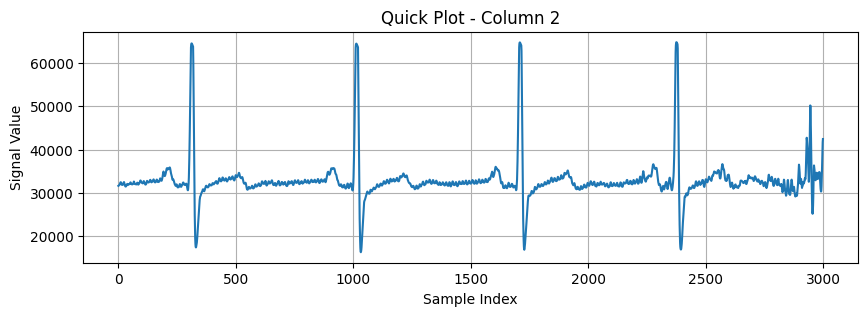

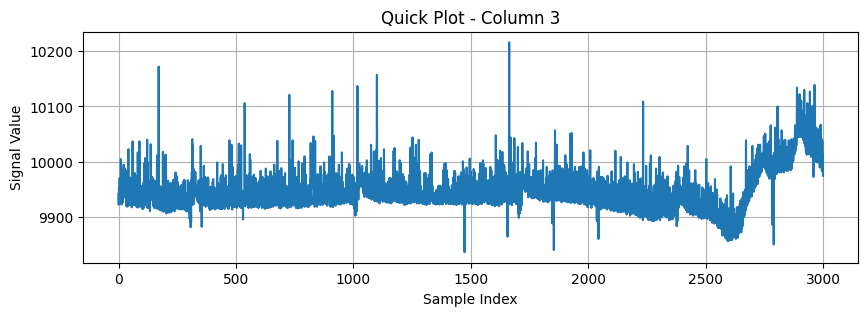

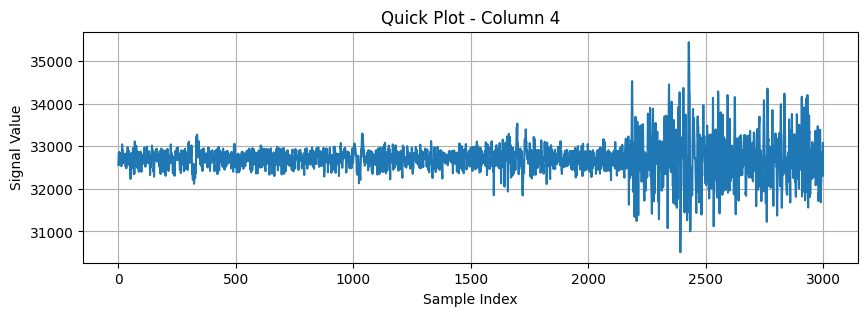

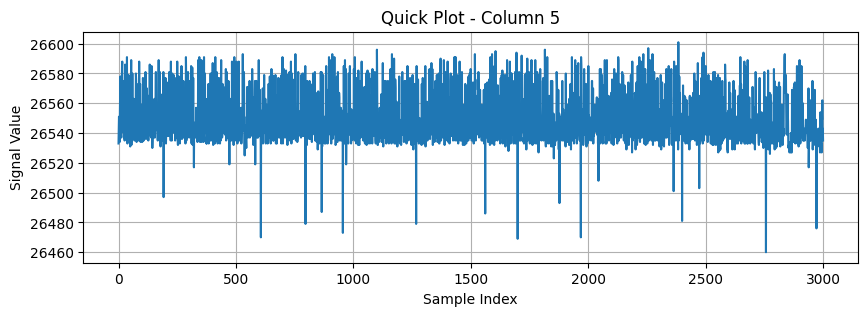

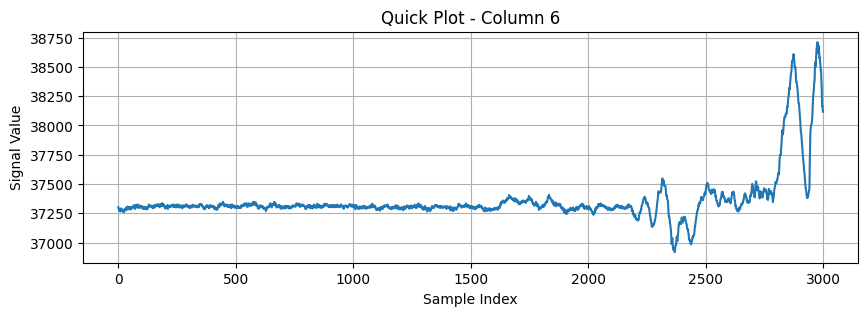

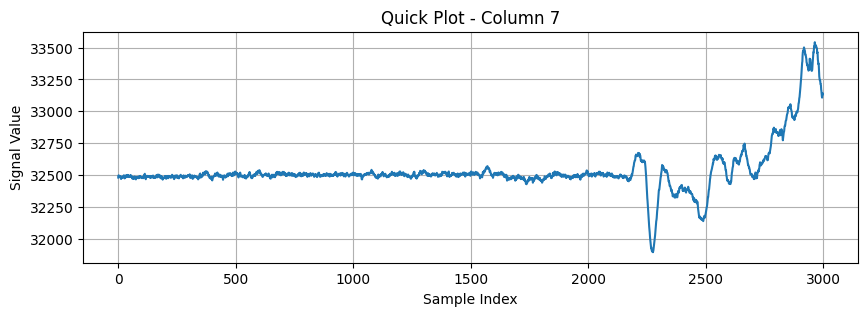

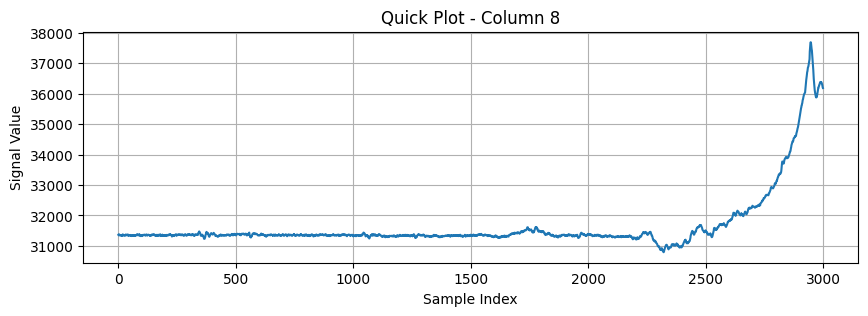

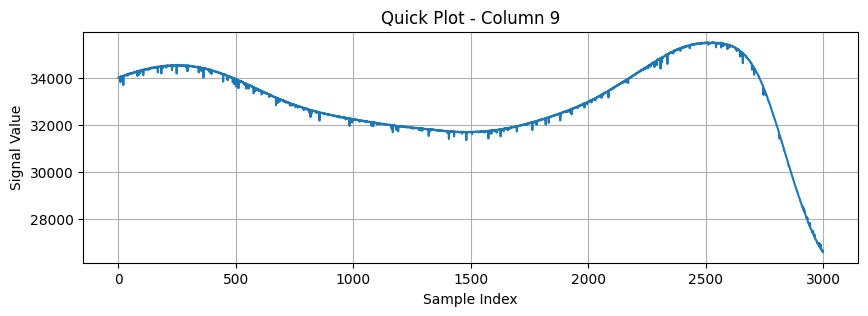

In [ ]:
##: Load and Preprocess RESP Signal ##
import pandas as pd
from scipy.signal import butter, filtfilt
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv("C:/Users/gunja/Desktop/Tecnomers internship/systematic lit review/WESAD DATA analysis/S5/S5_respiban.txt", delimiter="\t", comment="#", header=None)

resp_raw = df[9].values
resp_raw = resp_raw - np.mean(resp_raw)  # Center the signal

# Step 2: Check the number of columns
print(f"Number of columns detected: {df.shape[1]}")

# Step 3: Print first few rows
print(df.head())

# Step 4: Find which columns have valid (non-NaN) data
#valid_columns = df.columns[df.notna().any()].tolist()
valid_columns = df.columns[2:10].tolist()
print(f"Valid columns with real data: {valid_columns}")

# Step 5: Plot each valid column quickly to visually identify respiration
for col in valid_columns:
    plt.figure(figsize=(10, 3))
    plt.plot(df[col].values[:3000])  # Plot first 3000 samples
    plt.title(f"Quick Plot - Column {col}")
    plt.xlabel("Sample Index")
    plt.ylabel("Signal Value")
    plt.grid(True)
    plt.show()



First 10 values of resp_ds: 0     NaN
20    NaN
40    NaN
60    NaN
80    NaN
100   NaN
120   NaN
140   NaN
160   NaN
180   NaN
Name: 10, dtype: float64
Min value: nan
Max value: nan
Mean value: nan


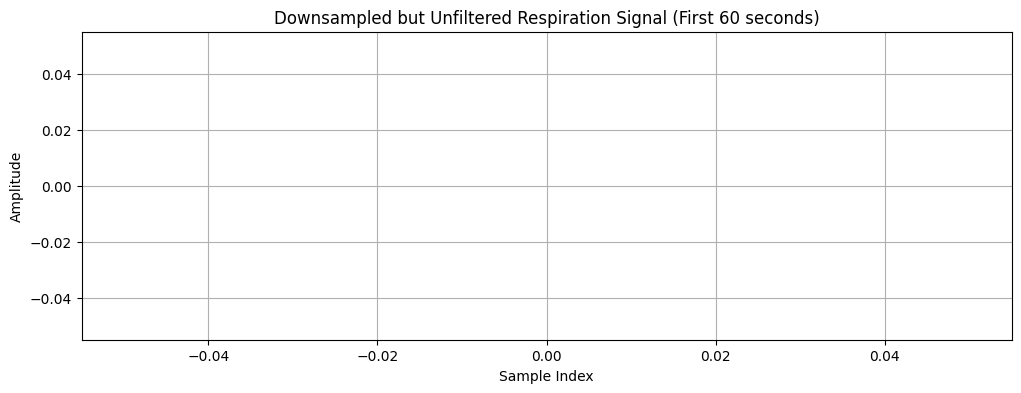

In [33]:
import matplotlib.pyplot as plt
import numpy as np
# Plot the downsampled (but not filtered) respiration signal
print("First 10 values of resp_ds:", resp_ds[:10])
print("Min value:", np.min(resp_ds))
print("Max value:", np.max(resp_ds))
print("Mean value:", np.mean(resp_ds))
plt.figure(figsize=(12, 4))
plt.plot(resp_ds[:2100])
plt.title("Downsampled but Unfiltered Respiration Signal (First 60 seconds)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

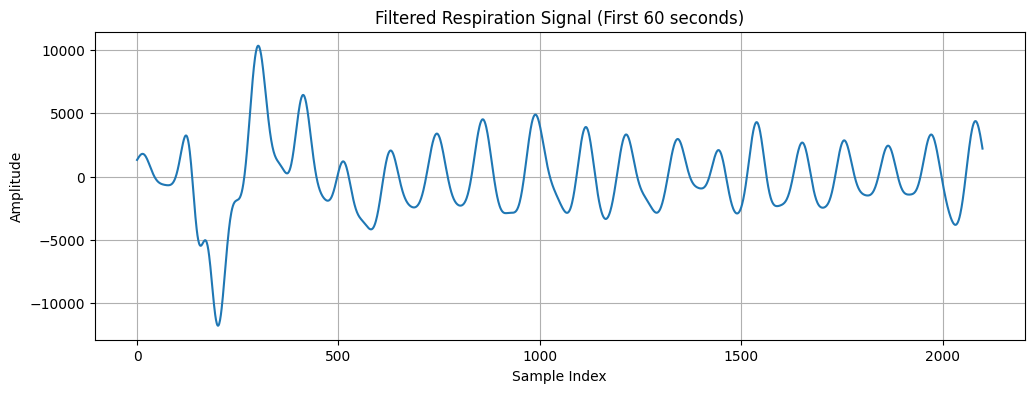

In [26]:
#Respiration Analysis
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("C:/Users/gunja/Desktop/Tecnomers internship/systematic lit review/WESAD DATA analysis/S5/S5_respiban.txt", delimiter="\t", comment="#", header=None)


# (Manual) Assume respiration is in column 8
resp_raw = df[9].values
resp_raw = resp_raw - np.mean(resp_raw)  # Center the signal

# Downsample
fs = 700
downsample_factor = 20
fs_ds = fs // downsample_factor
resp_ds = resp_raw[::downsample_factor]

# Bandpass filter
def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)

resp_filtered = bandpass_filter(resp_ds, 0.05, 0.8, fs_ds)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(resp_filtered[:fs_ds*60])
plt.title("Filtered Respiration Signal (First 60 seconds)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


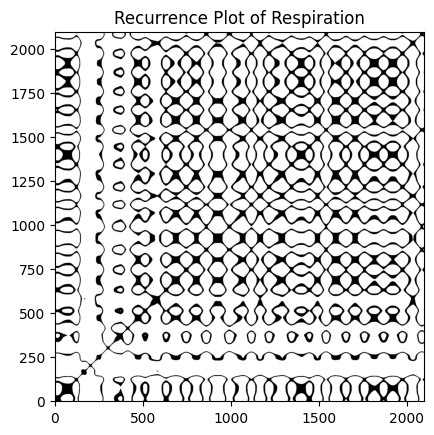

Feature summary:
breathing_rate_bpm: 17.14
mean_amplitude: 19737.41
amplitude_std: 2897.98
mean_bbi_sec: 3.5
bbi_std: 1.23
num_breaths_detected: 1837


In [27]:
#Recurrence plot Analysis of complete respiratory signal
from pyts.image import RecurrencePlot

rp = RecurrencePlot(threshold='point', percentage=20)
resp_reshaped = resp_filtered[:35*60].reshape(1, -1)  # 60s window
X_rp = rp.fit_transform(resp_reshaped)

plt.imshow(X_rp[0], cmap='binary', origin='lower')
plt.title("Recurrence Plot of Respiration")
plt.show()

#Extract Breathing Features (Use scipy.signal.find_peaks)
#You can extract breath rate, amplitude, and variability.

#Python Code: Breathing Feature Extraction

from scipy.signal import find_peaks

# Use the filtered respiration signal from before
signal = resp_filtered

# Detect peaks (inhalation points)
peaks, _ = find_peaks(signal, distance=fs_ds*1.5)  # 1.5s min between breaths

# Calculate breath-to-breath intervals (in seconds)
bbi = np.diff(peaks) / fs_ds

# Compute breathing rate (breaths per minute)
breathing_rate_bpm = 60 / np.mean(bbi) if len(bbi) > 0 else np.nan

# Compute amplitude of each breath
amplitudes = signal[peaks] - np.min(signal)  # relative to baseline

# Feature summary
print("Feature summary:")
features = {
    "breathing_rate_bpm": round(breathing_rate_bpm, 2),
    "mean_amplitude": round(np.mean(amplitudes), 2),
    "amplitude_std": round(np.std(amplitudes), 2),
    "mean_bbi_sec": round(np.mean(bbi), 2),
    "bbi_std": round(np.std(bbi), 2),
    "num_breaths_detected": len(peaks)
}

# Display
for k, v in features.items():
    print(f"{k}: {v}")


In [24]:
#Comparision of Breathing Features by Segment
#Step 2: Define Segment Windows
# Each segment = 5 minutes = 300 seconds → 300 * 35 samples
segment_length = 300 * fs_ds  # fs_ds = 35 Hz
segments = {
    "neutral": resp_filtered[0 : segment_length],
    "amusement": resp_filtered[segment_length : 2*segment_length],
    "stress": resp_filtered[2*segment_length : 3*segment_length]
}

#Step 3: Extract Features for Each Segment
def extract_breathing_features(signal, fs):
    peaks, _ = find_peaks(signal, distance=fs*1.5)
    bbi = np.diff(peaks) / fs if len(peaks) > 1 else [0]
    amplitudes = signal[peaks] - np.min(signal)
    return {
        "breathing_rate_bpm": round(60 / np.mean(bbi), 2) if np.mean(bbi) > 0 else np.nan,
        "mean_amplitude": round(np.mean(amplitudes), 2),
        "amplitude_std": round(np.std(amplitudes), 2),
        "mean_bbi_sec": round(np.mean(bbi), 2),
        "bbi_std": round(np.std(bbi), 2),
        "num_breaths": len(peaks)
    }

# Apply to all segments
features_by_segment = {label: extract_breathing_features(sig, fs_ds) for label, sig in segments.items()}

# Display
#import pandas as pd
df_features = pd.DataFrame(features_by_segment).T
print(df_features)


           breathing_rate_bpm  mean_amplitude  amplitude_std  mean_bbi_sec  \
neutral                 21.55         6094.69        1082.39          2.78   
amusement               21.32         7675.78        1016.34          2.81   
stress                  18.59         5834.13         713.94          3.23   

           bbi_std  num_breaths  
neutral       0.84        108.0  
amusement     0.62        106.0  
stress        0.62         93.0  


In [11]:
#Self-Similarity analysis using the filtered respiration signal.

# Reduce input to 20 seconds (700 samples originally → after downsampling ~700/20 = 35 Hz)
window_seconds = 20
fs_ds = 35 # Sampling frequency after downsampling
rp_samples = fs_ds * window_seconds

# Slice a smaller segment
segment = resp_filtered[:rp_samples].reshape(1, -1)

# Generate recurrence plot
rp = RecurrencePlot(threshold='point', percentage=20)
rp_matrix = rp.fit_transform(segment)

def recurrence_metrics(rp_matrix):
    N = rp_matrix.shape[0]
    RR = np.sum(rp_matrix) / (N * N)
    
    # Determinism: diagonal lines
    diagonals = [np.diag(rp_matrix[0], k) for k in range(1, N)]
    det_lines = [np.sum(d) for d in diagonals if np.sum(d) > 2]
    DET = np.sum(det_lines) / np.sum(rp_matrix)

    return {
        "Recurrence Rate": float(round(RR, 4)),
        "Determinism": float(round(DET, 4) )if DET < 1 else 1.0
    }

metrics = recurrence_metrics(rp_matrix[0])
print(metrics)



{'Recurrence Rate': 0.2, 'Determinism': 0.9272}
